In [2]:
# import torch
# import torch.optim as optim
# import ot
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.decomposition import PCA
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# # UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# # UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
# try:
#     import umap.umap_ as umap
#     UMAP_AVAILABLE = True
# except ImportError:
#     try:
#         import umap
#         UMAP_AVAILABLE = True
#     except ImportError:
#         print("UMAP not found. Falling back to PCA for visualization.")
#         UMAP_AVAILABLE = False

# # -----------------------------------------------------------------------------
# # 1. Setup Data
# # -----------------------------------------------------------------------------
# torch.manual_seed(42)
# np.random.seed(42)

# n_source = 20
# n_target = 30
# dim = 768
# EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# # [Target Data]: Target 클러스터 내부 분산을 10배 키워서 (0.1 -> 1.0) UMAP이 퍼뜨리도록 유도
# target_emb = torch.randn(n_target, dim) * 1.0 # 분산 증대 (이전 0.1)

# # Source Data (Learnable): Target과 겹쳐서 시작
# source_emb = torch.randn(n_source, dim, requires_grad=True)

# # 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
# with torch.no_grad():
#     source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# # Distribution weights
# p = ot.unif(n_source, type_as=source_emb)
# q = ot.unif(n_target, type_as=target_emb)

# # -----------------------------------------------------------------------------
# # 2. Training Loop (Robust Normalization)
# # -----------------------------------------------------------------------------
# optimizer = optim.SGD([source_emb], lr=0.5) 

# print("Start Training (UMAP Trajectory Enabled - Increased Target Variance)...")
# loss_history = []
# feat_cost_history = []
# struc_cost_history = []

# # [수정됨] 이동량 및 'Source-Target 거리' 분석을 위한 기록 저장소
# movement_history = {
#     'epoch': [],
#     'step_size': [],
#     'displacement': [],
#     'grad_norm': [],
#     'centroid_dist': [],   # Source 중심 - Target 중심 거리
#     'mean_pairwise_dist': [] # 전체적인 거리 평균
# }

# # Plan 시각화용
# snapshot_epochs = [0, 100, 1000, 2500, 4900]
# plan_snapshots = {}
# alpha = 1.0

# # 초기 상태
# source_history = [source_emb.detach().cpu().numpy().copy()]

# # 실제 GW Loss 항의 최대값 계산용 (참조)
# gw_cost_max = 0.0 

# # [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
# n_epochs = 5000
# for epoch in range(n_epochs):
#     optimizer.zero_grad()

#     # --- Matrix Computation ---
#     M_raw = ot.dist(source_emb, target_emb)
#     C1_raw = ot.dist(source_emb, source_emb)
#     C2_raw = ot.dist(target_emb, target_emb)

#     # Robust Max Normalization (NaN 방지)
#     M = M_raw / (M_raw.max() + EPSILON) 
#     C1 = C1_raw / (C1_raw.max() + EPSILON)
#     C2 = C2_raw / (C2_raw.max() + EPSILON)

#     # --- FGW Loss ---
#     fgw_loss = ot.gromov.fused_gromov_wasserstein2(
#         M, C1, C2, p, q,
#         loss_fun='square_loss', alpha=alpha
#     )

#     if torch.isnan(fgw_loss):
#         print("Loss is NaN! Stopping training.")
#         break

#     # --- Update ---
#     fgw_loss.backward()
#     optimizer.step()

#     loss_history.append(fgw_loss.item())

#     # [로그 출력]
#     if epoch % 100 == 0:
#         with torch.no_grad():
#             T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun = 'square_loss', alpha = alpha)
#             if epoch in snapshot_epochs:
#                 plan_snapshots[epoch] = T.detach().cpu().numpy() 
#             current_feat_cost = torch.sum(M * T).item() 
#             constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
#             current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item() 
#             feat_cost_history.append(current_feat_cost)
#             struc_cost_history.append(current_struc_cost)
#             weight_feat = (1 - alpha) * current_feat_cost 
#             weighted_struc = alpha * current_struc_cost 
#             total_weight = weighted_feat + weighted_struc + EPSILON
#             raw_m_max = M_raw.max().item()
#             c1_max_val = C1.max().item() 
#             gw_max_cost = (C1_raw.max().item() - C1_raw.min().item())**2
#             actual_ratio = gw_cost_max / (raw_m_max + EPSILON)
            
#             # --- [수정됨] Dynamics Analysis Calculation ---
#             curr_emb = source_emb.detach().cpu().numpy()
            
#             # 1. Movement Dynamics
#             diff = 0.0
#             if len(source_history) > 0:
#                 prev_emb = source_history[-1]
#                 diff = np.linalg.norm(curr_emb - prev_emb, axis=1).mean()
            
#             init_emb = source_history[0]
#             displacement = np.linalg.norm(curr_emb - init_emb, axis=1).mean()
            
#             grad_norm = 0.0
#             if source_emb.grad is not None:
#                 grad_norm = source_emb.grad.norm().item()

#             # 2. Proximity Analysis (Source vs Target Distance)
#             # (1) Centroid Distance: 중심점 간의 거리 (Translation 확인용)
#             s_mean = source_emb.mean(dim=0)
#             t_mean = target_emb.mean(dim=0)
#             c_dist = torch.norm(s_mean - t_mean).item()

#             # (2) Mean Pairwise Distance: 모든 점들 간의 거리 평균 (Global Alignment 확인용)
#             # M_raw는 이미 거리 제곱(sqeuclidean)일 수 있으므로 sqrt를 씌우거나, 
#             # ot.dist 구현에 따라 다름 (ot.dist는 squared euclidean distance 반환)
#             # 물리적 거리를 보기 위해 sqrt 적용
#             m_dist = torch.sqrt(M_raw).mean().item()

#             # 기록 저장
#             movement_history['epoch'].append(epoch)
#             movement_history['step_size'].append(diff)
#             movement_history['displacement'].append(displacement)
#             movement_history['grad_norm'].append(grad_norm)
#             movement_history['centroid_dist'].append(c_dist)
#             movement_history['mean_pairwise_dist'].append(m_dist)
#             # ---------------------------------------------

#             print("-" * 50)
#             print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
#             print("   [RAW COST SCALE COMPARISON]")
#             print(f"   1. Feature Cost (M) Max:       {raw_m_max:,.2f}")
#             print(f"   2. Structure Cost (GW) Max:    {gw_max_cost:,.2f}")
#             print(f"   3. Actual Ratio (GW / M):      {actual_ratio:,.2f}")
#             print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
            
#             print(f"   [Movement] Avg Step Size: {diff:.6f}")
#             print(f"   [Displacement] From Start: {displacement:.6f}")
#             print(f"   [Proximity] Centroid Dist: {c_dist:.4f} | Mean Pairwise: {m_dist:.4f}")
#             # --------------------------------
            
#             source_history.append(source_emb.detach().cpu().numpy().copy())

# # 최종 상태
# source_history.append(source_emb.detach().cpu().numpy().copy())
# print("-" * 50)
# print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# # -----------------------------------------------------------------------------
# # 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# # -----------------------------------------------------------------------------
# print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
# projection_method = "UMAP"

# # 모든 시점의 Source와 Target을 합쳐서 UMAP 수행
# all_data = np.vstack(source_history + [target_emb.numpy()])

# if UMAP_AVAILABLE:
#     reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
#     data_2d = reducer.fit_transform(all_data)
# else:
#     pca = PCA(n_components=2)
#     data_2d = pca.fit_transform(all_data)
#     projection_method = "PCA"

# # 데이터 분리
# target_2d = data_2d[-n_target:]
# source_2d_history = []
# start_idx = 0
# n_snapshots = len(source_history)
# for _ in range(n_snapshots):
#     end_idx = start_idx + n_source
#     source_2d_history.append(data_2d[start_idx:end_idx])
#     start_idx = end_idx

# source_2d_history = np.array(source_2d_history) 

# # 그래프 그리기
# plt.figure(figsize=(12, 8))
# ax = plt.gca() 

# # 1. Target (Goal)
# plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# # 2. Source Trajectories
# for i in range(n_source):
#     traj = source_2d_history[:, i, :]
#     plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)
#     plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
#     plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# ax.set_aspect('equal', adjustable='box') 

# plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
# plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
# plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

# plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}", fontsize=16)
# plt.legend(loc='upper right', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 4. Visualization: Cost Evolution (Dual Axis)
# # -----------------------------------------------------------------------------
# print("Visualizing Cost Evolution...")
# epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# color1 = 'tab:blue'
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Raw Feature Cost', color=color1, fontsize=12, fontweight='bold')
# ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx() 
# color2 = 'tab:red'
# ax2.set_ylabel('Raw Structure Cost', color=color2, fontsize=12, fontweight='bold')
# ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
# ax2.tick_params(axis='y', labelcolor=color2)

# plt.title(f"Cost Evolution (Alpha={alpha})", fontsize=16)
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 5. Visualization: Transport Plan Snapshots
# # -----------------------------------------------------------------------------
# if plan_snapshots:
#     print("Visualizing Transport Plans...")
#     def plot_single_plan(ax, matrix, title):
#         im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
#         ax.set_title(title, fontsize=12, pad=10)
#         ax.set_xlabel("Target Index", fontsize=10)
#         ax.set_ylabel("Source Index", fontsize=10)
#         divider = make_axes_locatable(ax)
#         cax = divider.append_axes("right", size="5%", pad=0.1)
#         cb = plt.colorbar(im, cax=cax)
#         return ax

#     n_snaps = len(plan_snapshots)
#     fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
#     if n_snaps == 1: axes = [axes]
    
#     sorted_epochs = sorted(plan_snapshots.keys())
#     for i, epoch in enumerate(sorted_epochs):
#         plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
#     plt.suptitle(f"Transport Plan Evolution (Alpha={alpha})", fontsize=16, y=1.02)
#     plt.show()

# # -----------------------------------------------------------------------------
# # 6. [업데이트됨] Visualization: Dynamics + Proximity (3 Subplots)
# # -----------------------------------------------------------------------------
# print("Visualizing Training Dynamics (Movement, Gradient, & Proximity)...")

# # 3개의 Subplot 생성 (3행 1열)
# fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# # [Graph A] Movement Dynamics
# ax_move = axes[0]
# ax_move.set_title(f"1. Embedding Movement Dynamics (Alpha={alpha})", fontsize=14, fontweight='bold')
# color_step = 'tab:green'
# ax_move.set_ylabel('Step Size (Speed)', color=color_step, fontsize=12)
# ax_move.plot(movement_history['epoch'], movement_history['step_size'], color=color_step, label='Step Size')
# ax_move.tick_params(axis='y', labelcolor=color_step)
# ax_move.grid(True, alpha=0.3)

# ax_disp = ax_move.twinx()
# color_disp = 'tab:purple'
# ax_disp.set_ylabel('Total Displacement', color=color_disp, fontsize=12)
# ax_disp.plot(movement_history['epoch'], movement_history['displacement'], color=color_disp, linewidth=2, label='Displacement')
# ax_disp.tick_params(axis='y', labelcolor=color_disp)
# ax_move.legend(loc='upper left')
# ax_disp.legend(loc='upper right')

# # [Graph B] Gradient Norm
# ax_grad = axes[1]
# ax_grad.set_title("2. Gradient Norm (Force)", fontsize=14, fontweight='bold')
# ax_grad.plot(movement_history['epoch'], movement_history['grad_norm'], 'orange', linewidth=2, label='Gradient Norm')
# ax_grad.set_ylabel('Norm Magnitude', fontsize=12)
# ax_grad.grid(True, alpha=0.3)
# ax_grad.legend()

# # [Graph C - 추가됨] Source vs Target Proximity (물리적 거리 차이)
# ax_prox = axes[2]
# ax_prox.set_title("3. Source-Target Proximity (Distance Gap)", fontsize=14, fontweight='bold')
# ax_prox.plot(movement_history['epoch'], movement_history['centroid_dist'], color='red', linewidth=2, linestyle='-', label='Centroid Distance (Global Shift)')
# ax_prox.plot(movement_history['epoch'], movement_history['mean_pairwise_dist'], color='blue', linewidth=2, linestyle='--', label='Mean Pairwise Dist (Average Gap)')
# ax_prox.set_ylabel('Euclidean Distance', fontsize=12)
# ax_prox.set_xlabel('Epoch', fontsize=12)
# ax_prox.grid(True, alpha=0.3)
# ax_prox.legend()

# plt.tight_layout()
# plt.show()

In [3]:
import torch
import torch.nn as nn

# 1. 설정 (Setup)
batch_size_s = 20  # Source 데이터 개수
batch_size_t = 15   # Target 데이터 개수
dim = 768          # 고차원 임베딩 (BERT 등)

print(f"--- [설정] Source: {batch_size_s}개, Target: {batch_size_t}개, 차원: {dim} ---")

# 2. 더미 데이터 생성 (Random High-dimensional Vectors)
# 실제 데이터처럼 분산을 좀 키워서(1.0) 생성
torch.manual_seed(42)
embs1 = torch.randn(batch_size_s, dim) 
embs2 = torch.randn(batch_size_t, dim)

print(f"\nInput Shapes: {embs1.shape}, {embs2.shape}")

# -------------------------------------------------------
# 3. 논문의 로직 단계별 실행 (Step-by-Step)
# -------------------------------------------------------

# [Step 1] 내적 계산 (Dot Product)
# (Batch1, Dim) x (Dim, Batch2) -> (Batch1, Batch2)
embs = torch.matmul(embs1, torch.t(embs2))

# [Step 2] 각 벡터의 자기 자신과의 내적 (Norm^2) 계산
# 논문 코드 방식 그대로 구현: diag(X * X.T) -> 각 벡터의 길이 제곱
embs_diag1 = torch.diag(torch.matmul(embs1, torch.t(embs1))).view(-1, 1).repeat(1, embs2.size(0))
embs_diag2 = torch.diag(torch.matmul(embs2, torch.t(embs2))).view(-1, 1).repeat(1, embs1.size(0))

# [Step 3] 유클리드 거리 제곱 (Squared Euclidean Distance)
# ||x - y||^2 = ||x||^2 + ||y||^2 - 2<x, y>
# Shape: (Batch1, Batch2)
distance_sq = embs_diag1 + torch.t(embs_diag2) - 2 * embs

print("\n=== [Step 3] Raw Squared Distance (L2^2) ===")
print(f"Shape: {distance_sq.shape}")
print(f"Values: Min={distance_sq.min().item():.2f}, Max={distance_sq.max().item():.2f}, Mean={distance_sq.mean().item():.2f}")
print(">> 해석: 768차원이라 거리 제곱값이 1,000~2,000 단위로 매우 큽니다.")


# [Step 4] 차원 수로 나누기 (Dimension Scaling)
# 논문의 핵심: 거리를 차원 수로 나눠 '평균 거리'로 만듦
scaled_distance = distance_sq / dim

print("\n=== [Step 4] Scaled Distance (/ dim) ===")
print(f"Shape: {scaled_distance.shape}")
print(f"Values: Min={scaled_distance.min().item():.4f}, Max={scaled_distance.max().item():.4f}")
print(">> 해석: 값을 차원 수(768)로 나누니 2.0 내외의 작은 숫자로 줄어들었습니다.")


# [Step 5] 커널 변환 (Kernel Transformation)
# Cost = 1 - exp(-dist)
# 0 -> 0, 무한대 -> 1 로 매핑
cost = 1 - torch.exp(-scaled_distance)

print("\n=== [Step 5] Final Cost (1 - exp(-x)) ===")
print(f"Shape: {cost.shape}")
print(f"Values: Min={cost.min().item():.4f}, Max={cost.max().item():.4f}")
print(">> 해석: 최종 값이 무조건 0.0 ~ 1.0 사이로 들어옵니다.")

# -------------------------------------------------------
# 값 직접 확인
# -------------------------------------------------------
print("\n[실제 행렬 값 일부 확인 (Top-Left 3x3)]")
print(cost[:3, :3])

--- [설정] Source: 20개, Target: 15개, 차원: 768 ---

Input Shapes: torch.Size([20, 768]), torch.Size([15, 768])

=== [Step 3] Raw Squared Distance (L2^2) ===
Shape: torch.Size([20, 15])
Values: Min=1356.59, Max=1853.62, Mean=1543.86
>> 해석: 768차원이라 거리 제곱값이 1,000~2,000 단위로 매우 큽니다.

=== [Step 4] Scaled Distance (/ dim) ===
Shape: torch.Size([20, 15])
Values: Min=1.7664, Max=2.4136
>> 해석: 값을 차원 수(768)로 나누니 2.0 내외의 작은 숫자로 줄어들었습니다.

=== [Step 5] Final Cost (1 - exp(-x)) ===
Shape: torch.Size([20, 15])
Values: Min=0.8291, Max=0.9105
>> 해석: 최종 값이 무조건 0.0 ~ 1.0 사이로 들어옵니다.

[실제 행렬 값 일부 확인 (Top-Left 3x3)]
tensor([[0.8610, 0.8502, 0.8711],
        [0.8582, 0.8595, 0.8754],
        [0.8466, 0.8422, 0.8598]])


In [4]:
cost.shape

torch.Size([20, 15])

Missing keys: ['latent_graph.node_embeddings', 'gnn_experts.graph_gnns.0.linear.weight', 'gnn_experts.graph_gnns.0.linear.bias', 'gnn_experts.graph_gnns.0.update.weight', 'gnn_experts.graph_gnns.0.update.bias', 'gnn_experts.graph_gnns.0.norm.weight', 'gnn_experts.graph_gnns.0.norm.bias', 'gnn_experts.graph_gnns.1.linear.weight', 'gnn_experts.graph_gnns.1.linear.bias', 'gnn_experts.graph_gnns.1.update.weight', 'gnn_experts.graph_gnns.1.update.bias', 'gnn_experts.graph_gnns.1.norm.weight', 'gnn_experts.graph_gnns.1.norm.bias', 'gnn_experts.graph_gnns.2.linear.weight', 'gnn_experts.graph_gnns.2.linear.bias', 'gnn_experts.graph_gnns.2.update.weight', 'gnn_experts.graph_gnns.2.update.bias', 'gnn_experts.graph_gnns.2.norm.weight', 'gnn_experts.graph_gnns.2.norm.bias', 'gnn_experts.graph_gnns.3.linear.weight', 'gnn_experts.graph_gnns.3.linear.bias', 'gnn_experts.graph_gnns.3.update.weight', 'gnn_experts.graph_gnns.3.update.bias', 'gnn_experts.graph_gnns.3.norm.weight', 'gnn_experts.graph_gnns

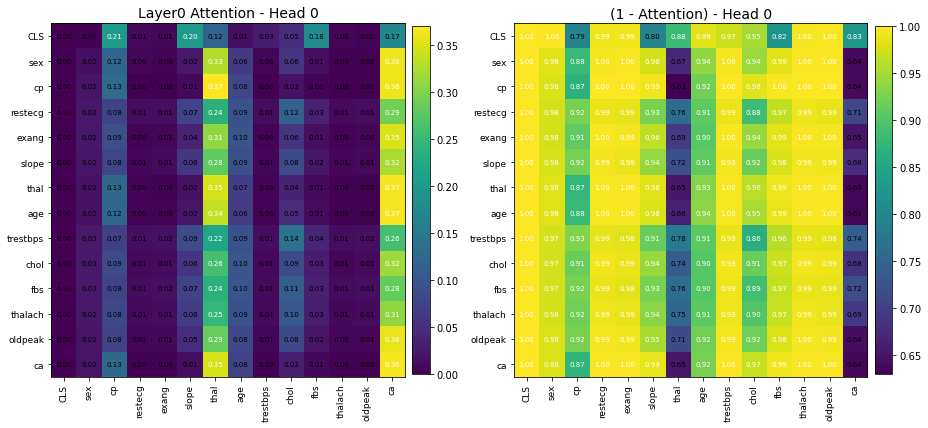

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0030 | std=0.2043
            sex  | mean=0.0363 | std=2.2336
             cp  | mean=0.2807 | std=5.9917
        restecg  | mean=0.3145 | std=6.4825
          exang  | mean=0.0740 | std=2.6730
          slope  | mean=0.2332 | std=5.7132
           thal  | mean=0.2306 | std=5.3918
            age  | mean=-0.1288 | std=6.3892
       trestbps  | mean=0.0095 | std=0.2759
           chol  | mean=-0.2017 | std=4.6270
            fbs  | mean=-0.0926 | std=2.2001
        thalach  | mean=0.6204 | std=14.2182
        oldpeak  | mean=-0.2213 | std=5.3015
             ca  | mean=-0.0438 | std=2.0763

=== Global embedding statistics ===
global mean: 0.0796
global std : 5.6961


In [5]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_kl_gamma-0.2_vq_beta-0.3_target_data-heart_description-None/42/best_20251119_141941.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=1, shuffle=False)

import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)




In [6]:
node = emb[1:]
print(node.shape)

(13, 768)


Start Training (UMAP Trajectory Enabled - Increased Target Variance)...
--------------------------------------------------
Epoch    0 | FGW Loss: 0.049815
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:       4,264.54
   2. Structure Cost (GW) Max:    1.23
   3. Actual Ratio (GW / M):      0.00
Epoch    0 | Total Loss: 0.049815
   [Movement] Avg Step Size: 13.764789
   [Displacement] From Start: 13.764789
   [Proximity] Centroid Dist: 7.1821 | Mean Pairwise: 37.5542
--------------------------------------------------
Epoch  100 | FGW Loss: 0.049725
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:       20,347.77
   2. Structure Cost (GW) Max:    1.36
   3. Actual Ratio (GW / M):      0.00
Epoch  100 | Total Loss: 0.049725
   [Movement] Avg Step Size: 98.277016
   [Displacement] From Start: 103.701828
   [Proximity] Centroid Dist: 10.9499 | Mean Pairwise: 118.7597
--------------------------------------------------
Epoch  200 | FGW Loss: 0.050542
   [RAW COST SCALE CO

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


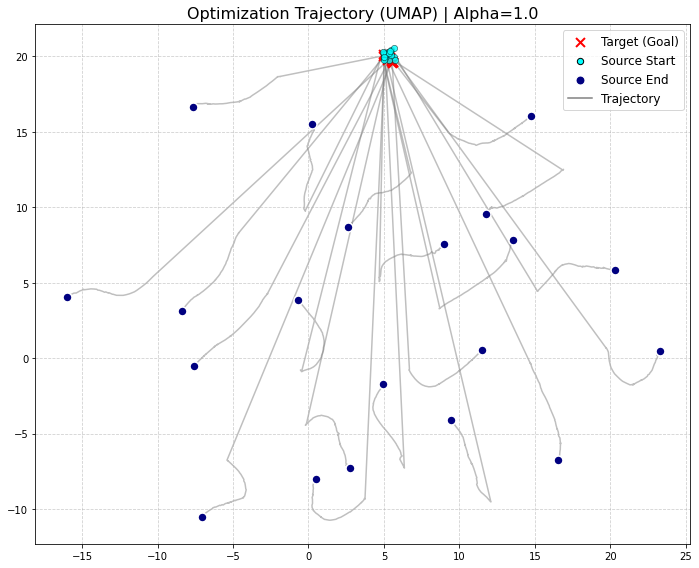

Visualizing Cost Evolution...


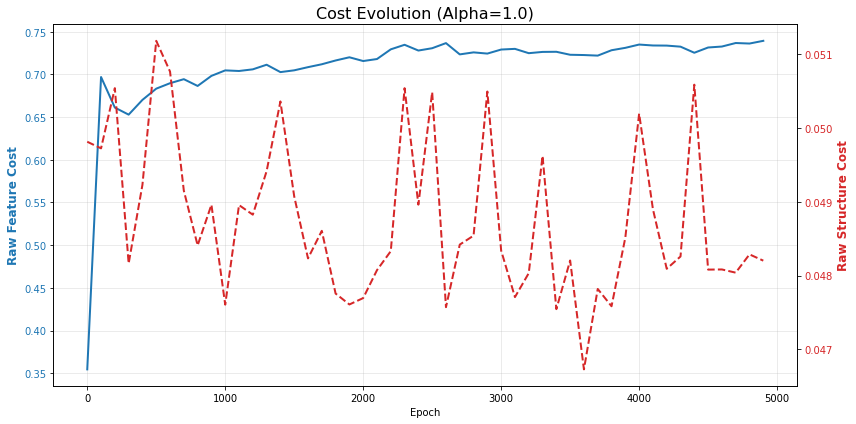

Visualizing Transport Plans...


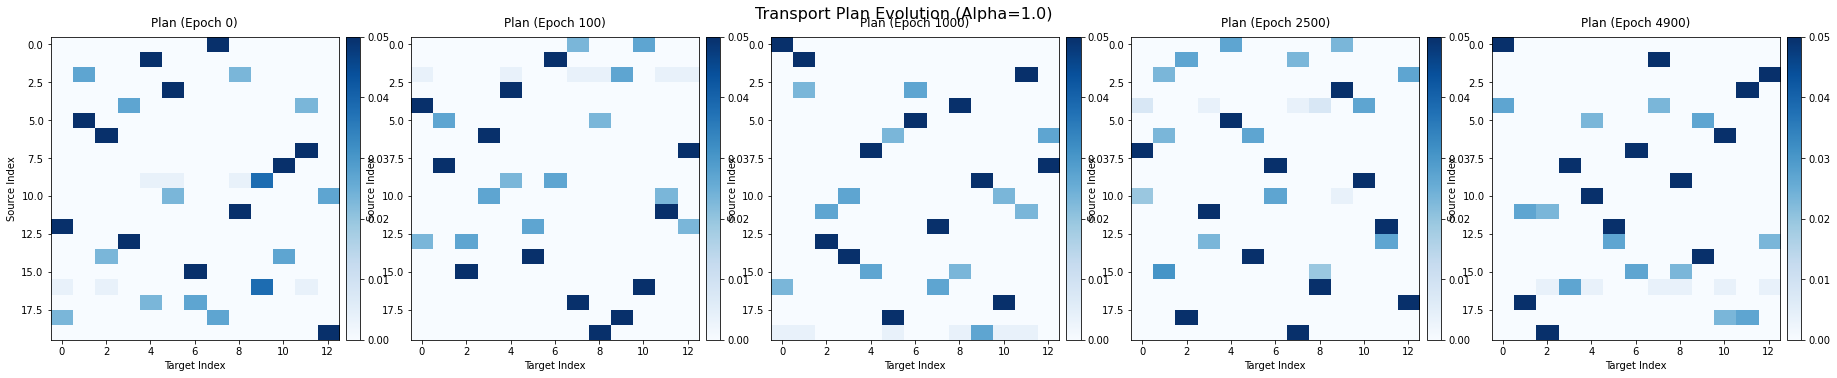

Visualizing Training Dynamics (Movement, Gradient, & Proximity)...


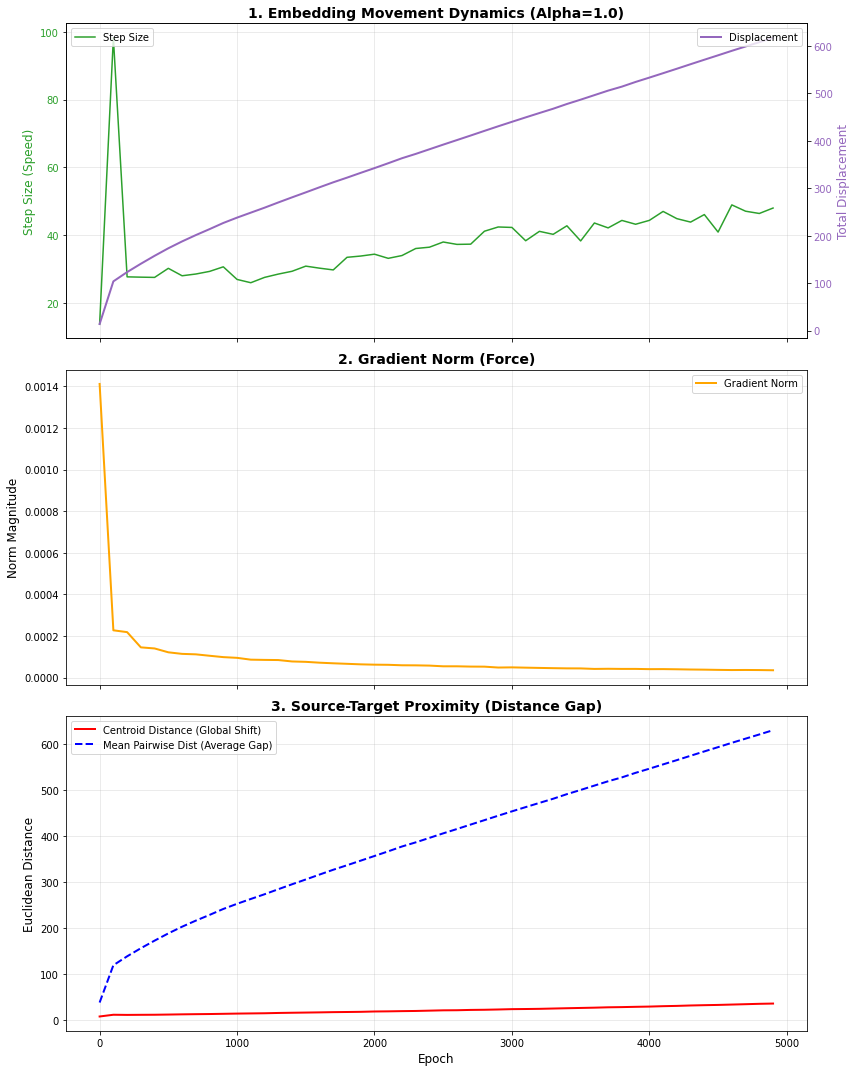

In [11]:
import torch
import torch.optim as optim
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.axes_grid1 import make_axes_locatable
# UMAP 확인
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA.")
        UMAP_AVAILABLE = False

# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = node.shape[0] # 13
dim = 768
EPSILON = 1e-9 

# [Target Data]
if isinstance(node, np.ndarray):
    target_emb = torch.from_numpy(node).float()
else:
    target_emb = node.detach().clone().float()

# [Target Standardization]
t_mean = target_emb.mean(dim=0)
t_std = target_emb.std(dim=0) + EPSILON
target_emb = (target_emb - t_mean) / t_std

# [Target Structure (C2)] Stretched 1-Affinity
attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# 1. Affinity -> Cost
C2_raw = 1.0 - attn_matrix 
C2_raw.fill_diagonal_(0.0) 

# (옵션) Setup 단계에서의 Min-Max Stretching은 데이터 전처리이므로 유지
# 이것은 "분포"를 0~1로 펴주는 것이지, 매 step마다 크기를 죽이는 Normalization과는 다름
# c2_min = C2_raw.min()
# c2_max = C2_raw.max()
# C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# [Source Data]
source_emb = torch.randn(n_source, dim, requires_grad=True)
with torch.no_grad():
    source_emb.data = torch.randn(n_source, dim)

# Weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=source_emb)

# Device
device = source_emb.device
target_emb = target_emb.to(device)
C2_raw = C2_raw.to(device)
def get_cosine_distance_matrix(x):
    # 1. Normalize vectors
    x_norm = F.normalize(x, p=2, dim=1)
    # 2. Similarity = X * X.T
    sim = torch.mm(x_norm, x_norm.t())
    # 3. Distance = 1 - Similarity (Range: 0~2)
    return 1.0 - sim
# -----------------------------------------------------------------------------
# 2. Training Loop
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# 2. Training Loop (Robust Normalization)
# -----------------------------------------------------------------------------
optimizer = optim.Adam([source_emb], lr=0.5) 

print("Start Training (UMAP Trajectory Enabled - Increased Target Variance)...")
loss_history = []
feat_cost_history = []
struc_cost_history = []

# [수정됨] 이동량 및 'Source-Target 거리' 분석을 위한 기록 저장소
movement_history = {
    'epoch': [],
    'step_size': [],
    'displacement': [],
    'grad_norm': [],
    'centroid_dist': [],   # Source 중심 - Target 중심 거리
    'mean_pairwise_dist': [] # 전체적인 거리 평균
}

# Plan 시각화용
snapshot_epochs = [0, 100, 1000, 2500, 4900]
plan_snapshots = {}
alpha = 1.0

# 초기 상태
source_history = [source_emb.detach().cpu().numpy().copy()]

# 실제 GW Loss 항의 최대값 계산용 (참조)
gw_cost_max = 0.0 

# [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
n_epochs = 5000
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # --- Matrix Computation ---
    M_raw = ot.dist(source_emb, target_emb)
    C1_raw = get_cosine_distance_matrix(source_emb)
    #C2_raw = ot.dist(target_emb, target_emb)

    # Robust Max Normalization (NaN 방지)
    M = M_raw / (M_raw.max() + EPSILON) 
    C1 = C1_raw / (C1_raw.max() + EPSILON)
    C2 = C2_raw / (C2_raw.max() + EPSILON)

    # --- FGW Loss ---
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping training.")
        break

    # --- Update ---
    fgw_loss.backward()
    optimizer.step()

    loss_history.append(fgw_loss.item())

    # [로그 출력]
    if epoch % 100 == 0:
        with torch.no_grad():
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun = 'square_loss', alpha = alpha)
            if epoch in snapshot_epochs:
                plan_snapshots[epoch] = T.detach().cpu().numpy() 
            current_feat_cost = torch.sum(M * T).item() 
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item() 
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            weighted_feat = (1 - alpha) * current_feat_cost 
            weighted_struc = alpha * current_struc_cost 
            total_weight = weighted_feat + weighted_struc + EPSILON
            raw_m_max = M_raw.max().item()
            c1_max_val = C1.max().item() 
            gw_max_cost = (C1_raw.max().item() - C1_raw.min().item())**2
            actual_ratio = gw_cost_max / (raw_m_max + EPSILON)
            
            # --- [수정됨] Dynamics Analysis Calculation ---
            curr_emb = source_emb.detach().cpu().numpy()
            
            # 1. Movement Dynamics
            diff = 0.0
            if len(source_history) > 0:
                prev_emb = source_history[-1]
                diff = np.linalg.norm(curr_emb - prev_emb, axis=1).mean()
            
            init_emb = source_history[0]
            displacement = np.linalg.norm(curr_emb - init_emb, axis=1).mean()
            
            grad_norm = 0.0
            if source_emb.grad is not None:
                grad_norm = source_emb.grad.norm().item()

            # 2. Proximity Analysis (Source vs Target Distance)
            # (1) Centroid Distance: 중심점 간의 거리 (Translation 확인용)
            s_mean = source_emb.mean(dim=0)
            t_mean = target_emb.mean(dim=0)
            c_dist = torch.norm(s_mean - t_mean).item()

            # (2) Mean Pairwise Distance: 모든 점들 간의 거리 평균 (Global Alignment 확인용)
            # M_raw는 이미 거리 제곱(sqeuclidean)일 수 있으므로 sqrt를 씌우거나, 
            # ot.dist 구현에 따라 다름 (ot.dist는 squared euclidean distance 반환)
            # 물리적 거리를 보기 위해 sqrt 적용
            m_dist = torch.sqrt(M_raw).mean().item()

            # 기록 저장
            movement_history['epoch'].append(epoch)
            movement_history['step_size'].append(diff)
            movement_history['displacement'].append(displacement)
            movement_history['grad_norm'].append(grad_norm)
            movement_history['centroid_dist'].append(c_dist)
            movement_history['mean_pairwise_dist'].append(m_dist)
            # ---------------------------------------------

            print("-" * 50)
            print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
            print("   [RAW COST SCALE COMPARISON]")
            print(f"   1. Feature Cost (M) Max:       {raw_m_max:,.2f}")
            print(f"   2. Structure Cost (GW) Max:    {gw_max_cost:,.2f}")
            print(f"   3. Actual Ratio (GW / M):      {actual_ratio:,.2f}")
            print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
            
            print(f"   [Movement] Avg Step Size: {diff:.6f}")
            print(f"   [Displacement] From Start: {displacement:.6f}")
            print(f"   [Proximity] Centroid Dist: {c_dist:.4f} | Mean Pairwise: {m_dist:.4f}")
            # --------------------------------
            
            source_history.append(source_emb.detach().cpu().numpy().copy())

# 최종 상태
source_history.append(source_emb.detach().cpu().numpy().copy())
print("-" * 50)
print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# -----------------------------------------------------------------------------
print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
projection_method = "UMAP"

# 모든 시점의 Source와 Target을 합쳐서 UMAP 수행
all_data = np.vstack(source_history + [target_emb.numpy()])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
else:
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

# 데이터 분리
target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx

source_2d_history = np.array(source_2d_history) 

# 그래프 그리기
plt.figure(figsize=(12, 8))
ax = plt.gca() 

# 1. Target (Goal)
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# 2. Source Trajectories
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

ax.set_aspect('equal', adjustable='box') 

plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}", fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Cost Evolution (Dual Axis)
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Raw Feature Cost', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Raw Structure Cost', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha})", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. Visualization: Transport Plan Snapshots
# -----------------------------------------------------------------------------
if plan_snapshots:
    print("Visualizing Transport Plans...")
    def plot_single_plan(ax, matrix, title):
        im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Target Index", fontsize=10)
        ax.set_ylabel("Source Index", fontsize=10)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cb = plt.colorbar(im, cax=cax)
        return ax

    n_snaps = len(plan_snapshots)
    fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    if n_snaps == 1: axes = [axes]
    
    sorted_epochs = sorted(plan_snapshots.keys())
    for i, epoch in enumerate(sorted_epochs):
        plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
    plt.suptitle(f"Transport Plan Evolution (Alpha={alpha})", fontsize=16, y=1.02)
    plt.show()

# -----------------------------------------------------------------------------
# 6. [업데이트됨] Visualization: Dynamics + Proximity (3 Subplots)
# -----------------------------------------------------------------------------
print("Visualizing Training Dynamics (Movement, Gradient, & Proximity)...")

# 3개의 Subplot 생성 (3행 1열)
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# [Graph A] Movement Dynamics
ax_move = axes[0]
ax_move.set_title(f"1. Embedding Movement Dynamics (Alpha={alpha})", fontsize=14, fontweight='bold')
color_step = 'tab:green'
ax_move.set_ylabel('Step Size (Speed)', color=color_step, fontsize=12)
ax_move.plot(movement_history['epoch'], movement_history['step_size'], color=color_step, label='Step Size')
ax_move.tick_params(axis='y', labelcolor=color_step)
ax_move.grid(True, alpha=0.3)

ax_disp = ax_move.twinx()
color_disp = 'tab:purple'
ax_disp.set_ylabel('Total Displacement', color=color_disp, fontsize=12)
ax_disp.plot(movement_history['epoch'], movement_history['displacement'], color=color_disp, linewidth=2, label='Displacement')
ax_disp.tick_params(axis='y', labelcolor=color_disp)
ax_move.legend(loc='upper left')
ax_disp.legend(loc='upper right')

# [Graph B] Gradient Norm
ax_grad = axes[1]
ax_grad.set_title("2. Gradient Norm (Force)", fontsize=14, fontweight='bold')
ax_grad.plot(movement_history['epoch'], movement_history['grad_norm'], 'orange', linewidth=2, label='Gradient Norm')
ax_grad.set_ylabel('Norm Magnitude', fontsize=12)
ax_grad.grid(True, alpha=0.3)
ax_grad.legend()

# [Graph C - 추가됨] Source vs Target Proximity (물리적 거리 차이)
ax_prox = axes[2]
ax_prox.set_title("3. Source-Target Proximity (Distance Gap)", fontsize=14, fontweight='bold')
ax_prox.plot(movement_history['epoch'], movement_history['centroid_dist'], color='red', linewidth=2, linestyle='-', label='Centroid Distance (Global Shift)')
ax_prox.plot(movement_history['epoch'], movement_history['mean_pairwise_dist'], color='blue', linewidth=2, linestyle='--', label='Mean Pairwise Dist (Average Gap)')
ax_prox.set_ylabel('Euclidean Distance', fontsize=12)
ax_prox.set_xlabel('Epoch', fontsize=12)
ax_prox.grid(True, alpha=0.3)
ax_prox.legend()

plt.tight_layout()
plt.show()

In [ ]:
#https://github.com/HongtengXu/gwl/blob/master/model/GromovWassersteinLearning.py